# 개요
파인튜닝 평가


5번 코드에서 생성한 테스트 데이터 평가하는 코드

```
- 비대상 테스트 데이터 : data1B, data_3B, data_8B, data_8B_Alpha
Llama-3.2-1B-Instruct_with_exec.zip
Llama-3.2-3B-Instruct_with_exec.zip
Llama-3.1-8B-Instruct_with_exec.zip
Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip

너희는 나의 실수다.

- 대상 테스트 데이터 : data_1B_2, data_3B_2, data_8B_ce, data_8B_Alpha_2
Llama-3.2-1B-Instruct_with_exec2.zip
Llama-3.2-3B-Instruct_with_exec2.zip
Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip
Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip
`
테스트 데이터 제작 시 SQL DB 방언 sqlite 변환에 GPT-5.4 모델 사용.
configuration 재설정으로 학습률/학습 시간 증가.
```

#0. 환경설정

In [1]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 4.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

In [3]:
import os
os.environ["OPENAI_API_KEY"] = ""

#1.데이터 불러오기

In [4]:
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/f621ee0a362638d49bc94cd4f3644e545db8e876/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/e521c1be8768bbc4bd65d09da1d1627d5a6add32/5.FineTuning_result/Llama-3.2-3B-Instruct/Llama-3.2-3B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/e521c1be8768bbc4bd65d09da1d1627d5a6add32/5.FineTuning_result/Llama-3.1-8B-Instruct/Llama-3.1-8B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/6715758fb5c54ec97fbb967c6f6390ba998b0ba0/5.FineTuning_result/Llama-3-Alpha-Ko-8B-Instruct/Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip

!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-3B-Instruct/Llama-3.2-3B-Instruct_with_exec2.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/8671e8d5446cdf831861d82603614d04d68681ba/5.FineTuning_result/Llama-3.1-8B-Instruct-config-edit/Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/7e5fce5c41599c42f4f19d396e43f71976adfead/5.FineTuning_result/Llama-3-Alpha-Ko-8B-Instruct/Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip

--2026-07-07 07:04:19--  https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip [following]
--2026-07-07 07:04:19--  https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... 

In [5]:
import zipfile

zip_file_path_whole = [#'Llama-3.2-1B-Instruct_with_exec.zip', 'Llama-3.2-3B-Instruct_with_exec.zip', 'Llama-3.1-8B-Instruct_with_exec.zip', 'Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip',
                       'Llama-3.2-1B-Instruct_with_exec2.zip', 'Llama-3.2-3B-Instruct_with_exec2.zip', 'Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip', 'Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip']
for zip_file_path in zip_file_path_whole:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
      zip_ref.extractall('.')
  print(f"Extracted all contents of {zip_file_path} to current directory.")

Extracted all contents of Llama-3.2-1B-Instruct_with_exec2.zip to current directory.
Extracted all contents of Llama-3.2-3B-Instruct_with_exec2.zip to current directory.
Extracted all contents of Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip to current directory.
Extracted all contents of Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip to current directory.


In [6]:
import pandas as pd

# data_1B = pd.read_csv('Llama-3.2-1B-Instruct_with_exec.csv')
# data_3B = pd.read_csv('Llama-3.2-3B-Instruct_with_exec.csv')
# data_8B = pd.read_csv('Llama-3.1-8B-Instruct_with_exec.csv')
# data_8B_Alpha = pd.read_csv('Llama-3-Alpha-Ko-8B-Instruct_with_exec.csv')

data_1B_original = pd.read_csv('Llama-3.2-1B-Instruct_with_exec2.csv')
data_3B_original = pd.read_csv('Llama-3.2-3B-Instruct_with_exec2.csv')
data_8B_original = pd.read_csv('Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.csv')
data_8B_Alpha_original = pd.read_csv('Llama-3-Alpha-Ko-8B-Instruct_with_exec2.csv')

In [7]:
#데이터 정제
data_1B = data_1B_original.copy()
data_1B = data_1B[data_1B['label_status'].str.contains('success')]

data_3B = data_3B_original.copy()
data_3B = data_3B[data_3B['label_status'].str.contains('success')]

data_8B = data_8B_original.copy()
data_8B = data_8B[data_8B['label_status'].str.contains('success')]

data_8B_Alpha = data_8B_Alpha_original.copy()
data_8B_Alpha = data_8B_Alpha[data_8B_Alpha['label_status'].str.contains('success')]

print(f"data_1B: {len(data_1B)}개")
print(f"data_3B: {len(data_3B)}개")
print(f"data_8B: {len(data_8B)}개")
print(f"data_8B_Alpha: {len(data_8B_Alpha)}개")

data_1B: 472개
data_3B: 472개
data_8B: 472개
data_8B_Alpha: 472개


#2. 결과 EDA

```
error 종류
1. success : 성공
2. success(converted) : sqlite 형식으로 변환해서 성공
3. error : SQL too long (** chars) : 비정상적으로 긴 SQL
4. error: Execution failed on sql <SQL문> : SQL문 실행 오류
5. error: wrong format (no '쿼리 작성:' prefix)
```

In [ ]:
data_8B.head(3)

,index,prompt,response,label,response_tables,response_exec_result,response_status,label_tables,label_exec_result,label_status,match
0,0,<|begin_of_text|><|start_header_id|>system<|en...,"쿼리 작성: select seller_city, seller_state, selle...","\n쿼리 작성: SELECT LOWER(SUBSTRING(seller_city, 1...",sellers,"seller_city,seller_state,seller_zip_code_prefi...",success,sellers,"initial,seller_count\ns,1072\nc,365\nb,233\nr,...",success,False
1,1,<|begin_of_text|><|start_header_id|>system<|en...,쿼리 작성: SELECT product_id\nFROM products\nWHERE...,\n쿼리 작성: SELECT product_id\nFROM products\nWHE...,products,product_id\n005030ef108f58b46b78116f754d8d38\n...,success,products,product_id\n005030ef108f58b46b78116f754d8d38\n...,success,True
2,2,<|begin_of_text|><|start_header_id|>system<|en...,"쿼리 작성: SELECT\n c.customer_city,\n AVG(TIMES...","\n쿼리 작성: SELECT\n c.customer_city,\n AVG(TIM...","customers,orders","customer_city,avg_hours_to_carrier\nonda verde...",success(converted),"customers,orders","customer_city,avg_hours_to_carrier\nonda verde...",success(converted),True


# 3. 평가1 - response_status_ratio

/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/2826561248.py:53: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  pl

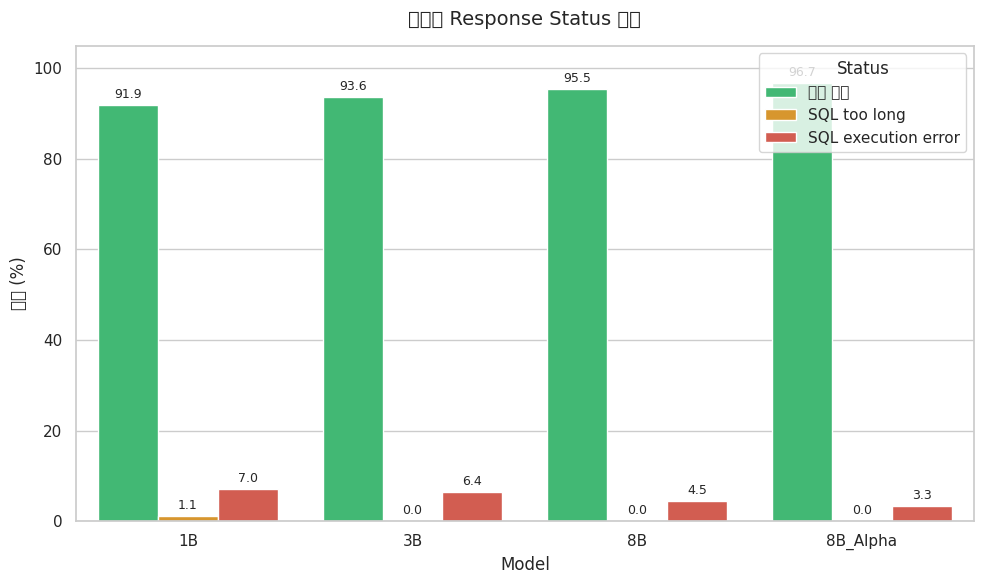

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. JSON 불러오기 =====
with open("test1_response_status_ratio.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# ===== 2. 카테고리 통합: success + success(converted) → 실행 성공 =====
processed = {}
for model, stats in raw_data.items():
    processed[model] = {
        "실행 성공":            round(stats.get("success", 0) + stats.get("success(converted)", 0), 1),
        "SQL too long":         stats.get("SQL too long", 0),
        "SQL execution error":  stats.get("SQL execution error", 0),
    }

# ===== 3. Seaborn용 long-format DataFrame으로 변환 =====
records = []
for model, stats in processed.items():
    for status, ratio in stats.items():
        records.append({"model": model, "status": status, "ratio": ratio})
df_plot = pd.DataFrame(records)

# ===== 4. 시각화 =====
sns.set_theme(style="whitegrid", font="DejaVu Sans")

fig, ax = plt.subplots(figsize=(10, 6))
palette = {
    "success/success(converted)":            "#2ecc71",
    "SQL too long":         "#f39c12",
    "SQL execution error":  "#e74c3c",
}

sns.barplot(
    data=df_plot,
    x="model", y="ratio", hue="status",
    palette=palette,
    ax=ax,
)

# 막대 위에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

ax.set_title("모델별 Response Status 비율", fontsize=14, pad=15)
ax.set_xlabel("Model")
ax.set_ylabel("비율 (%)")
ax.set_ylim(0, 105)
ax.legend(title="Status", loc="upper right")

plt.tight_layout()
plt.savefig("test1_response_status_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

#4. 평가2 - response_tables와 label_tables 일치도 모델별로

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. 테이블 일치도 분석 =====
def analyze_tables_match(df: pd.DataFrame) -> dict:
    """
    response_tables와 label_tables의 일치 정도 분석.

    카테고리:
    - exact_match:  완전히 같음
    - subset:       response ⊂ label (부족)
    - superset:     response ⊃ label (초과)
    - overlap:      일부 겹침
    - no_match:     겹치는 테이블 없음
    - empty:        response 또는 label이 비어있음
    """
    categories = {
        "exact_match": 0,
        "subset":      0,
        "superset":    0,
        "overlap":     0,
        "no_match":    0,
        "empty":       0,
    }

    for _, row in df.iterrows():
        resp_str  = str(row.get('response_tables', '') or '')
        label_str = str(row.get('label_tables', '')  or '')

        resp_set  = set(t.strip() for t in resp_str.split(',')  if t.strip())
        label_set = set(t.strip() for t in label_str.split(',') if t.strip())

        if not resp_set or not label_set:
            categories["empty"] += 1
        elif resp_set == label_set:
            categories["exact_match"] += 1
        elif resp_set < label_set:
            categories["subset"] += 1
        elif resp_set > label_set:
            categories["superset"] += 1
        elif resp_set & label_set:
            categories["overlap"] += 1
        else:
            categories["no_match"] += 1

    # 비율(%)로 변환
    total = len(df)
    return {k: round(v / total * 100, 1) for k, v in categories.items()}


# ===== 2. 모델별 분석 =====
model_dfs = {
    "1B":       data_1B,
    "3B":       data_3B,
    "8B":       data_8B,
    "8B_Alpha": data_8B_Alpha,
}

tables_match_ratio = {model: analyze_tables_match(df) for model, df in model_dfs.items()}

# ===== 3. JSON 저장 =====
output_json = "test2_tables_match_ratio.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(tables_match_ratio, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_json}")
print(json.dumps(tables_match_ratio, ensure_ascii=False, indent=2))

저장 완료: test2_tables_match_ratio.json
{
  "1B": {
    "exact_match": 96.8,
    "subset": 2.8,
    "superset": 0.0,
    "overlap": 0.2,
    "no_match": 0.2,
    "empty": 0.0
  },
  "3B": {
    "exact_match": 99.8,
    "subset": 0.2,
    "superset": 0.0,
    "overlap": 0.0,
    "no_match": 0.0,
    "empty": 0.0
  },
  "8B": {
    "exact_match": 99.6,
    "subset": 0.2,
    "superset": 0.0,
    "overlap": 0.0,
    "no_match": 0.2,
    "empty": 0.0
  },
  "8B_Alpha": {
    "exact_match": 99.6,
    "subset": 0.2,
    "superset": 0.2,
    "overlap": 0.0,
    "no_match": 0.0,
    "empty": 0.0
  }
}


/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15834/1800744440.py:51: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tig

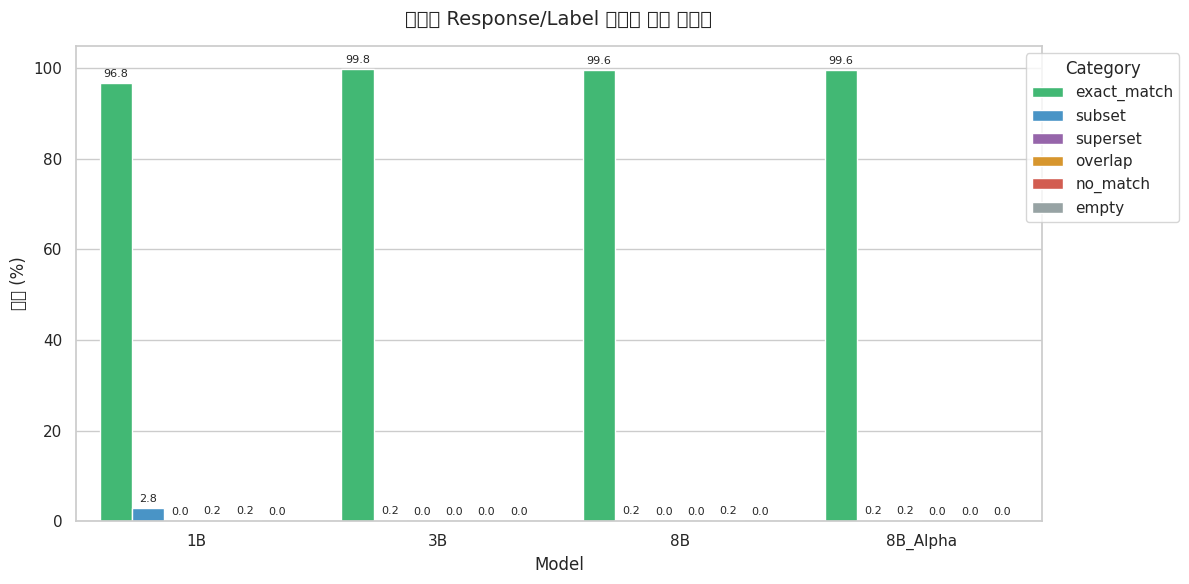

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. JSON 로드 =====
with open("test2_tables_match_ratio.json", "r", encoding="utf-8") as f:
    tables_match_ratio = json.load(f)

# ===== 2. long-format DataFrame으로 변환 =====
records = []
for model, stats in tables_match_ratio.items():
    for category, ratio in stats.items():
        records.append({"model": model, "category": category, "ratio": ratio})
df_plot = pd.DataFrame(records)

# 카테고리 순서 지정
category_order = ["exact_match", "subset", "superset", "overlap", "no_match", "empty"]

# ===== 3. 시각화 =====
sns.set_theme(style="whitegrid", font="DejaVu Sans")

fig, ax = plt.subplots(figsize=(12, 6))
palette = {
    "exact_match": "#2ecc71",  # 초록 (완벽)
    "subset":      "#3498db",  # 파랑 (부족)
    "superset":    "#9b59b6",  # 보라 (초과)
    "overlap":     "#f39c12",  # 주황 (일부)
    "no_match":    "#e74c3c",  # 빨강 (전혀)
    "empty":       "#95a5a6",  # 회색 (없음)
}

sns.barplot(
    data=df_plot,
    x="model", y="ratio", hue="category",
    hue_order=category_order,
    palette=palette,
    ax=ax,
)

# 막대 위에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

ax.set_title("모델별 Response/Label 테이블 사용 일치도", fontsize=14, pad=15)
ax.set_xlabel("Model")
ax.set_ylabel("비율 (%)")
ax.set_ylim(0, 105)
ax.legend(title="Category", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.savefig("test2_tables_match_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

#4.LLM 사용 준비

In [9]:
import re
#Llama chat template 프롬프트에서 query와 ddl 추출.
def parse_prompt(text: str) -> tuple[str, str]:

    query_match = re.search(
        r"입력 텍스트:\s*(.+?)(?=\s*\n+\s*DDL statements:|\s*$)",
        text,
        flags=re.DOTALL,
    )
    query = query_match.group(1).strip() if query_match else ""

    ddl_match = re.search(
        r"DDL statements:\s*(.+?)(?=\s*\n+\s*위의 테이블 명세)",
        text,
        flags=re.DOTALL,
    )
    ddl_statement = ddl_match.group(1).strip() if ddl_match else ""

    return query, ddl_statement

#4. LLM-as-a-Judge

##4-1. 평가3 - response 품질

In [ ]:
import pandas as pd
import re
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

# ===== 프롬프트 정의 (전역) =====
SYSTEM_PROMPT = """
#역할
당신은 Text-to-SQL FineTuning 평가자입니다.
입력된 정보들을 보고 LLM이 올바르게 Fine Tuning 되었는지 평가해주세요.

prompt는 입력된 프롬프트, ddl_statement는 사용된 DB의 DDL문과 예시 값입니다.
response는 Fine-Tuning된 모델의 응답, label은 모범 정답입니다.

#평가 기준
1. response가 prompt의 요구사항을 충족하는지
2. response가 label과 동일한 의도/결과를 제공하는지
3. ddl statement를 보았을 때 response가 존재하는 컬럼/테이블을 참조하는지
4. response의 SQL 형식/문법이 올바른지
5. response가 prompt에서 요구하는 조건을 충족하는지 (LIMIT, ORDER BY, DISTINCT 등)

#출력 형식
평가 기준 별 만족 여부와 그 이유를 적고 만족한 평가 기준 개수로 총점을 매겨주세요.총점은 무조건 정수 하나로만 대답하세요
예시)
[평가]
1 - 만족. 이유.
2 - 불만족. 이유.
3 - 만족. 이유.
...
[총점]
4
"""

HUMAN_PROMPT = """
prompt : {prompt}
ddl_statement : {ddl_statement}
response : {response}
label : {label}
"""


def extract_score(evaluation: str) -> int | None:
    """LLM 평가 결과 텍스트에서 [총점] 뒤의 정수를 추출."""
    if not isinstance(evaluation, str):
        return None
    # [총점] 다음에 오는 첫 정수 매칭
    match = re.search(r"\[총점\]\s*(\d+)", evaluation)
    return int(match.group(1)) if match else None


def evaluate_with_llm(df: pd.DataFrame, output_csv: str, model: str = "gpt-5.4-nano") -> pd.DataFrame:
    """
    LLM으로 Fine-Tuning 결과를 평가하고 CSV로 저장.

    Args:
        df:         평가할 DataFrame (prompt, response, label 컬럼 필요)
        output_csv: 결과 저장 경로
        model:      사용할 OpenAI 모델 (기본: gpt-5.4-nano)

    Returns:
        평가 결과가 담긴 DataFrame
    """
    # 1. LLM 체인 구성
    llm = ChatOpenAI(model=model, temperature=0)
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",  HUMAN_PROMPT),
    ])
    chain = prompt_template | llm | StrOutputParser()

    print(f"평가 대상: {len(df)}개")

    # 2. 평가 루프
    evaluations = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="LLM 평가"):
        prompt_text, ddl_statement = parse_prompt(row['prompt'])

        try:
            evaluation = chain.invoke({
                "prompt":        prompt_text,
                "ddl_statement": ddl_statement,
                "response":      row['response'],
                "label":         row['label'],
            })
        except Exception as e:
            evaluation = f"[ERROR] {e}"

        # 총점 추출
        score = extract_score(evaluation)

        evaluations.append({
            "index":      row['index'],
            "prompt":     prompt_text,
            "ddl":        ddl_statement,
            "response":   row['response'],
            "label":      row['label'],
            "evaluation": evaluation,
            "score":      score,
        })

    # 3. 결과 저장
    df_result = pd.DataFrame(evaluations)
    df_result.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"\n완료: {output_csv} ({len(df_result)}개 평가 완료)")

    # 4. 간단 요약
    valid_scores = df_result['score'].dropna()
    if len(valid_scores) > 0:
        print(f"\n=== 점수 통계 ===")
        print(f"평균:   {valid_scores.mean():.2f}")
        print(f"중앙값: {valid_scores.median():.1f}")
        print(f"분포:")
        print(valid_scores.value_counts().sort_index())

    return df_result

In [ ]:
result_1B = evaluate_with_llm(data_1B, "Llama-3.2-1B-Instruct_llm_eval.csv", model = "gpt-5.4-nano")

평가 대상: 472개


LLM 평가: 100%|██████████| 472/472 [28:50<00:00,  3.67s/it]


완료: Llama-3.2-1B-Instruct_llm_eval.csv (472개 평가 완료)

=== 점수 통계 ===
평균:   1.98
중앙값: 1.0
분포:
score
0     39
1    208
2    109
3     23
4     27
5     66
Name: count, dtype: int64


In [ ]:
result_3B = evaluate_with_llm(data_3B, "Llama-3.2-3B-Instruct_llm_eval.csv", model = "gpt-5.4-nano")

평가 대상: 472개


LLM 평가: 100%|██████████| 472/472 [30:14<00:00,  3.84s/it]


완료: Llama-3.2-3B-Instruct_llm_eval.csv (472개 평가 완료)

=== 점수 통계 ===
평균:   2.56
중앙값: 2.0
분포:
score
0     13
1    143
2    125
3     40
4     62
5     89
Name: count, dtype: int64


In [ ]:
result_8B = evaluate_with_llm(data_8B, "Llama-3.1-8B-Instruct_llm_eval.csv", model = "gpt-5.4-nano")

평가 대상: 472개


LLM 평가: 100%|██████████| 472/472 [31:08<00:00,  3.96s/it]


완료: Llama-3.1-8B-Instruct_llm_eval.csv (472개 평가 완료)

=== 점수 통계 ===
평균:   2.86
중앙값: 2.5
분포:
score
0     13
1    109
2    114
3     50
4     66
5    120
Name: count, dtype: int64


In [ ]:
result_8B_Alpha = evaluate_with_llm(data_8B_Alpha, "Llama-3-Alpha-Ko-8B-Instruct_llm_eval.csv", model = "gpt-5.4-nano")

평가 대상: 472개


LLM 평가: 100%|██████████| 472/472 [26:46<00:00,  3.40s/it]


완료: Llama-3-Alpha-Ko-8B-Instruct_llm_eval.csv (472개 평가 완료)

=== 점수 통계 ===
평균:   2.77
중앙값: 2.0
분포:
score
0      9
1    106
2    132
3     64
4     58
5    103
Name: count, dtype: int64


##4-2. 평가4 - response & label match 여부
단순 일치로는 평가가 불가능해 LLM으로 비교 필요

대상 : response_exec_result & label_exec_result

변수명은 달라도 일단 내용은 같은 경우가 있는 것을 체크.



In [10]:
for i in [10,20,30]:
  prompt_text, ddl_statement = parse_prompt(data_8B_Alpha['prompt'][i])
  print(prompt_text)
  print()
  print(data_8B_Alpha['response_exec_result'][i])
  print(data_8B_Alpha['label_exec_result'][i])

2017년 4분기 고객별 총 결제 금액 상위 5명과 각 고객의 해당 기간 배송 완료 주문 수

customer_id,total_payment,delivered_orders
1617b1357756262bfa56ab541c47bc16,13664.08,1
05455dfa7cd02f13d132aa7a6a9729c6,6081.54,1
46bb3c0b1a65c8399d0363cefbcc4f37,3297.3999999999996,1
0a209a88c2e3dc2981c79ad85c558059,3126.5,1
10a86619816f9d2afce3f45b04aabc71,3126.5,1

customer_id,total_payment,delivered_order_count
05455dfa7cd02f13d132aa7a6a9729c6,6081.54,1
46bb3c0b1a65c8399d0363cefbcc4f37,3297.3999999999996,2
c26acf0451e0f8ec1f5218731b9a51cf,3184.55,1
10a86619816f9d2afce3f45b04aabc71,3126.5,1
0a209a88c2e3dc2981c79ad85c558059,3126.5,1

SP와 RJ 두 주에서 모두 나타나는 고유 고객 수는 몇 명이니?

unique_customers
3

shared_unique_customers
3

2017년 12월에 구매된 주문 기준 결제수단별 구매 시각부터 결제 승인까지 평균 소요 시간과 해당 수단을 사용한 서로 다른 고객 수.

payment_type,avg_hours_to_approval,distinct_customer_count
boleto,35.762225577985426,1159
credit_card,4.355455845328496,4357
debit_card,6.645598958129995,64
voucher,11.030888131876685,220

affected_rows=-1


In [ ]:
exec_result 너무 긴거 자르기 필요


In [ ]:
4. 차이가 발생한 부분의 원인 추정
- DB 상태 변경으로 설명 가능한 차이인지 (행이 추가/삭제되어 순위가 바뀐 경우 등)
- 모델의 의도가 잘못된 경우인지 (필터링 조건/집계 방식이 본질적으로 다른 경우)

In [25]:
import pandas as pd
import re
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

# ===== 프롬프트 정의 (전역) =====
SYSTEM_PROMPT = """
#역할
당신은 Text-to-SQL FineTuning 평가자입니다.
response_exec_result를 정답인 label_exec_result와 비교해 충분한 결과를 반환받았는지 평가해주세요.

prompt는 입력된 프롬프트입니다.
response_exec_result는 Fine-Tuning된 모델에 prompt를 넣고 리턴받은 SQL문을 DB에 실행한 결과입니다.
label_exec_result는 정답 SQL문을 DB에 실행한 정답 결과입니다.

#평가 기준
각 평가기준에 대해 판단할 수 없는 경우 기본 만족함으로 진행.

1. 칼럼의 일치 여부
- 칼럼명이 다르더라도 같은 정보를 표현하는가?
- 정답 칼럼을 충분히 포함하고 있는가? (예: delivered_orders vs delivered_order_count)

2. 핵심 데이터의 일치 여부
- 두 결과 사이에 겹치는 행이 충분히 존재하는가
- 겹치는 행에서 주요 수치가 유사한가 (소수점/반올림 차이는 허용)

3. 정렬 및 순서의 일관성
- prompt에 정렬 기준이 명시되어 있을 경우 동일하게 적용되었는가.
- prompt에 정렬 기준이 명시되어 있지 않다면 만족
- 동률(tie)이 있을 경우 다른 행이 선택되는 것은 허용

#판단 가이드
- 컬럼 구조와 의도가 일치하고, 결과의 대부분이 일치하면 True
- 일부 행이 다르거나 수치가 미세하게 다르더라도 의도가 일치하면 True
- 컬럼 의미 자체가 다르거나, 결과의 본질이 다르면 False

#출력 형식
[평가]
1 - 만족/불만족. 이유.
2 - 만족/불만족. 이유.
3 - 만족/불만족. 이유.

[매칭]
True 또는 False
"""

HUMAN_PROMPT = """
prompt : {prompt}
response_exec_result : {response_exec_result}
label_exec_result : {label_exec_result}
"""



In [27]:
def extract_match(evaluation: str) -> bool | None:
    """LLM 평가 결과에서 [매칭] True/False 추출."""
    if not isinstance(evaluation, str):
        return None
    m = re.search(r"\[매칭\]\s*(True|False)", evaluation, flags=re.IGNORECASE)
    if not m:
        return None
    return m.group(1).lower() == "true"


def evaluate_match_with_llm(df: pd.DataFrame, output_csv: str, model: str = "gpt-4o-mini") -> pd.DataFrame:
    """
    LLM으로 두 SQL 실행 결과의 매칭 여부를 평가하고 CSV로 저장.

    Args:
        df:         평가할 DataFrame (prompt, response_exec_result, label_exec_result 컬럼 필요)
        output_csv: 결과 저장 경로
        model:      사용할 OpenAI 모델 (기본: gpt-4o-mini)

    Returns:
        평가 결과가 담긴 DataFrame
    """
    # 1. LLM 체인 구성
    llm = ChatOpenAI(model=model, temperature=0)
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",  HUMAN_PROMPT),
    ])
    chain = prompt_template | llm | StrOutputParser()

    print(f"평가 대상: {len(df)}개")

    # 2. 평가 루프
    evaluations = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="LLM 매칭 평가"):
        prompt_text, _ = parse_prompt(row['prompt'])

        try:
            evaluation = chain.invoke({
                "prompt":               prompt_text,
                "response_exec_result": row['response_exec_result'],
                "label_exec_result":    row['label_exec_result'],
            })
        except Exception as e:
            evaluation = f"[ERROR] {e}"

        # 매칭 여부 추출
        match_llm = extract_match(evaluation)

        evaluations.append({
            "index":                row['index'],
            "prompt":               prompt_text,
            "response_exec_result": row['response_exec_result'],
            "label_exec_result":    row['label_exec_result'],
            "match":                row.get('match', None),
            "evaluation":           evaluation,
            "match_llm":            match_llm,
        })

    # 3. 결과 저장
    df_result = pd.DataFrame(evaluations)
    df_result.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"\n완료: {output_csv} ({len(df_result)}개 평가 완료)")

    # 4. 간단 요약
    valid = df_result['match_llm'].dropna()
    if len(valid) > 0:
        print(f"\n=== 매칭 결과 ===")
        print(f"LLM 판단 True:  {(valid == True).sum()}개")
        print(f"LLM 판단 False: {(valid == False).sum()}개")
        print(f"매칭율:         {(valid == True).mean() * 100:.1f}%")

        if 'match' in df_result.columns and df_result['match'].notna().any():
            both = df_result.dropna(subset=['match', 'match_llm'])
            agree = (both['match'].astype(bool) == both['match_llm']).sum()
            print(f"\n기존 match와 일치: {agree}/{len(both)}개 ({agree/len(both)*100:.1f}%)")

    return df_result

In [28]:
if not os.path.exists('LLM-as-a-Judge'):
    os.mkdir('LLM-as-a-Judge')

In [ ]:
data_1B, data_3B, data_8B, data_8B_Alpha에 대해 아래 코드를 다 작성해줘,

result_8b = evaluate_match_with_llm(data_8B, "LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv","gpt-5.4-nano")

In [30]:
result_1B = evaluate_match_with_llm(
    data_1B,
    "LLM-as-a-Judge/Llama-3.2-1B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [17:27<00:00,  2.22s/it]



완료: LLM-as-a-Judge/Llama-3.2-1B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  136개
LLM 판단 False: 286개
매칭율:         32.2%

기존 match와 일치: 329/422개 (78.0%)


In [31]:
result_3B = evaluate_match_with_llm(
    data_3B,
    "LLM-as-a-Judge/Llama-3.2-3B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:54<00:00,  2.15s/it]



완료: LLM-as-a-Judge/Llama-3.2-3B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  226개
LLM 판단 False: 200개
매칭율:         53.1%

기존 match와 일치: 296/426개 (69.5%)


In [32]:
result_8B = evaluate_match_with_llm(
    data_8B,
    "LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:10<00:00,  2.06s/it]



완료: LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  257개
LLM 판단 False: 184개
매칭율:         58.3%

기존 match와 일치: 301/441개 (68.3%)


In [33]:
result_8B_Alpha = evaluate_match_with_llm(
    data_8B_Alpha,
    "LLM-as-a-Judge/Llama-3-Alpha-Ko-8B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:54<00:00,  2.15s/it]



완료: LLM-as-a-Judge/Llama-3-Alpha-Ko-8B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  249개
LLM 판단 False: 178개
매칭율:         58.3%

기존 match와 일치: 274/427개 (64.2%)
